In [20]:
import pandas as pd

In [21]:
calendar = pd.read_csv("calendar.csv")

In [22]:
calendar.head()

,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [23]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         731 non-null    object
 1   year         731 non-null    int64 
 2   month        731 non-null    int64 
 3   day          731 non-null    int64 
 4   week         731 non-null    int64 
 5   day_of_week  731 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 34.4+ KB


In [25]:
format="%d-%m-%Y"

In [26]:
calendar.head()

,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [27]:
calendar["date"] = pd.to_datetime(calendar["date"])

In [28]:
calendar["date"] = pd.to_datetime(
    calendar["date"],
    format="mixed",
    dayfirst=True
)

In [29]:
calendar["date"].head(10)

,date
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
5,2023-01-06
6,2023-01-07
7,2023-01-08
8,2023-01-09
9,2023-01-10


In [30]:
calendar["date"] = pd.to_datetime(calendar["date"])

In [31]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         731 non-null    datetime64[ns]
 1   year         731 non-null    int64         
 2   month        731 non-null    int64         
 3   day          731 non-null    int64         
 4   week         731 non-null    int64         
 5   day_of_week  731 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 34.4 KB


In [32]:
calendar["month_name"] = calendar["date"].dt.month_name()

calendar["day_name"] = calendar["date"].dt.day_name()

calendar["quarter"] = calendar["date"].dt.quarter

calendar["is_weekend"] = calendar["day_of_week"].isin([5, 6])

calendar["month_year"] = calendar["date"].dt.strftime("%b-%Y")

calendar["year_month"] = calendar["date"].dt.strftime("%Y-%m")

calendar["day_of_year"] = calendar["date"].dt.dayofyear

In [33]:
calendar.head()

,date,year,month,day,week,day_of_week,month_name,day_name,quarter,is_weekend,month_year,year_month,day_of_year
0,2023-01-01,2023,1,1,52,6,January,Sunday,1,True,Jan-2023,2023-01,1
1,2023-01-02,2023,1,2,1,0,January,Monday,1,False,Jan-2023,2023-01,2
2,2023-01-03,2023,1,3,1,1,January,Tuesday,1,False,Jan-2023,2023-01,3
3,2023-01-04,2023,1,4,1,2,January,Wednesday,1,False,Jan-2023,2023-01,4
4,2023-01-05,2023,1,5,1,3,January,Thursday,1,False,Jan-2023,2023-01,5


In [34]:
calendar.isnull().sum()

,0
date,0
year,0
month,0
day,0
week,0
day_of_week,0
month_name,0
day_name,0
quarter,0
is_weekend,0


In [35]:
calendar["date"].duplicated().sum()

np.int64(0)

In [36]:
calendar.to_csv("calendar_final.csv", index=False)

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [8]:
with open("Superstore Sales Dataset.csv", "rb") as f:
    print(f.read(500))

b'Row ID;Order ID;Order Date;Ship Date;Month & Year Order;Ship Mode;Customer ID;Customer Name;Segment;Country;City;State;Postal Code;Region;Product ID;Category;Sub-Category;Product Name;Sales\r\n1;CA-2017-152156;08/11/2017;11/11/2017;November 2017;Second Class;CG-12520;Claire Gute;Consumer;United States;Henderson;Kentucky;42420;South;FUR-BO-10001798;Furniture;Bookcases;Bush Somerset Collection Bookcase; $26,196 \r\n2;CA-2017-152156;08/11/2017;11/11/2017;November 2017;Second Class;CG-12520;Claire Gute;'


In [9]:
with open("Superstore Sales Dataset.csv", "r", encoding="latin1") as f:
    for i in range(5):
        print(f.readline())

Row ID;Order ID;Order Date;Ship Date;Month & Year Order;Ship Mode;Customer ID;Customer Name;Segment;Country;City;State;Postal Code;Region;Product ID;Category;Sub-Category;Product Name;Sales

1;CA-2017-152156;08/11/2017;11/11/2017;November 2017;Second Class;CG-12520;Claire Gute;Consumer;United States;Henderson;Kentucky;42420;South;FUR-BO-10001798;Furniture;Bookcases;Bush Somerset Collection Bookcase; $26,196 

2;CA-2017-152156;08/11/2017;11/11/2017;November 2017;Second Class;CG-12520;Claire Gute;Consumer;United States;Henderson;Kentucky;42420;South;FUR-CH-10000454;Furniture;Chairs;Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back; $73,194 

3;CA-2017-138688;12/06/2017;16/06/2017;June 2017;Second Class;DV-13045;Darrin Van Huff;Corporate;United States;Los Angeles;California;90036;West;OFF-LA-10000240;Office Supplies;Labels;Self-Adhesive Address Labels for Typewriters by Universal; $1,462 

4;US-2016-108966;11/10/2016;18/10/2016;October 2016;Standard Class;SO-20335;Sean O'Donnell

In [10]:
import pandas as pd

df = pd.read_csv(
    "Superstore Sales Dataset.csv",
    sep=None,
    engine="python",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Month & Year Order,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,November 2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,"$26,196"
1,2,CA-2017-152156,08/11/2017,11/11/2017,November 2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...","$73,194"
2,3,CA-2017-138688,12/06/2017,16/06/2017,June 2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,"$1,462"
3,4,US-2016-108966,11/10/2016,18/10/2016,October 2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,"$9,575,775"
4,5,US-2016-108966,11/10/2016,18/10/2016,October 2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,"$22,368"


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Row ID              9800 non-null   int64  
 1   Order ID            9800 non-null   object 
 2   Order Date          9800 non-null   object 
 3   Ship Date           9800 non-null   object 
 4   Month & Year Order  9800 non-null   object 
 5   Ship Mode           9800 non-null   object 
 6   Customer ID         9800 non-null   object 
 7   Customer Name       9800 non-null   object 
 8   Segment             9800 non-null   object 
 9   Country             9800 non-null   object 
 10  City                9800 non-null   object 
 11  State               9800 non-null   object 
 12  Postal Code         9789 non-null   float64
 13  Region              9800 non-null   object 
 14  Product ID          9800 non-null   object 
 15  Category            9800 non-null   object 
 16  Sub-Ca

In [12]:
df.describe()

,Row ID,Postal Code
count,9800.000000,9789.000000
mean,4900.500000,55273.322403
std,2829.160653,32041.223413
min,1.000000,1040.000000
25%,2450.750000,23223.000000
50%,4900.500000,58103.000000
75%,7350.250000,90008.000000
max,9800.000000,99301.000000


In [13]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Month & Year Order,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0


In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [15]:
df["Order Date"].head()

,Order Date
0,2017-11-08
1,2017-11-08
2,2017-06-12
3,2016-10-11
4,2016-10-11


In [16]:
df["Sales"] = (
    df["Sales"]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

In [17]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,object
Month & Year Order,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object


In [18]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Weekday"] = df["Order Date"].dt.dayofweek

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Month & Year Order,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Day,Weekday
0,1,CA-2017-152156,2017-11-08,11/11/2017,November 2017,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,26196.0,2017,11,8,2
1,2,CA-2017-152156,2017-11-08,11/11/2017,November 2017,Second Class,CG-12520,Claire Gute,Consumer,United States,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",73194.0,2017,11,8,2
2,3,CA-2017-138688,2017-06-12,16/06/2017,June 2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,1462.0,2017,6,12,0
3,4,US-2016-108966,2016-10-11,18/10/2016,October 2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,9575775.0,2016,10,11,1
4,5,US-2016-108966,2016-10-11,18/10/2016,October 2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22368.0,2016,10,11,1


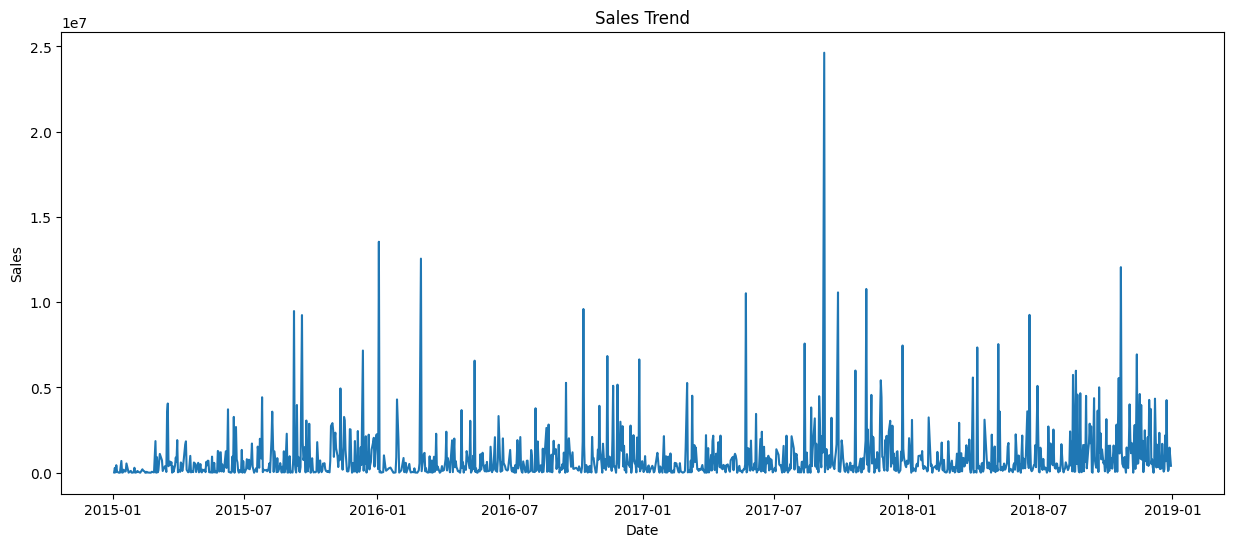

In [20]:
monthly_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"])
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [21]:
X = df[["Year", "Month", "Day", "Weekday"]]

y = df["Sales"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 173184.97457957742
MSE: 204568012099.45828
R2 Score: -0.21670584204177756


In [26]:
df["Sales"].head(10)

,Sales
0,26196.0
1,73194.0
2,1462.0
3,9575775.0
4,22368.0
5,4886.0
6,728.0
7,907152.0
8,18504.0
9,1149.0


In [27]:
df[["Product Name", "Sales"]].head(10)

,Product Name,Sales
0,Bush Somerset Collection Bookcase,26196.0
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",73194.0
2,Self-Adhesive Address Labels for Typewriters b...,1462.0
3,Bretford CR4500 Series Slim Rectangular Table,9575775.0
4,Eldon Fold 'N Roll Cart System,22368.0
5,Eldon Expressions Wood and Plastic Desk Access...,4886.0
6,Newell 322,728.0
7,Mitel 5320 IP Phone VoIP phone,907152.0
8,DXL Angle-View Binders with Locking Rings by S...,18504.0
9,Belkin F5C206VTEL 6 Outlet Surge,1149.0


In [28]:
df["Sales"].describe()

,Sales
count,9.800000e+03
mean,1.137515e+05
std,5.218849e+05
min,3.000000e+00
25%,2.544000e+03
50%,1.110950e+04
75%,5.405700e+04
max,2.396266e+07


In [29]:
df["Sales"].describe()

,Sales
count,9.800000e+03
mean,1.137515e+05
std,5.218849e+05
min,3.000000e+00
25%,2.544000e+03
50%,1.110950e+04
75%,5.405700e+04
max,2.396266e+07


In [30]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16448.0
1,2015-01-04,284874.0
2,2015-01-05,19536.0
3,2015-01-06,440710.0
4,2015-01-07,77771.0


In [31]:
daily_sales["Year"] = daily_sales["Order Date"].dt.year
daily_sales["Month"] = daily_sales["Order Date"].dt.month
daily_sales["Day"] = daily_sales["Order Date"].dt.day
daily_sales["Weekday"] = daily_sales["Order Date"].dt.dayofweek

In [32]:
X = daily_sales[["Year", "Month", "Day", "Weekday"]]
y = daily_sales["Sales"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1053258.0253658537
MSE: 4690859890104.402
R2 Score: -0.13361495450342953


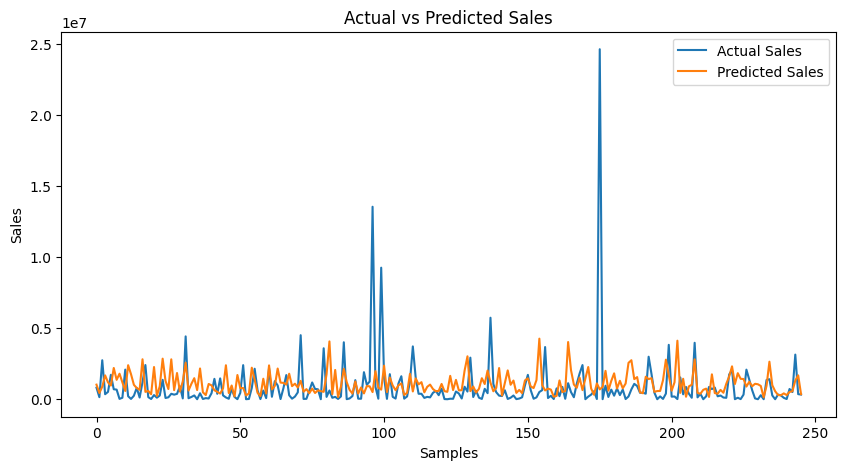

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Samples")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [38]:
future = pd.DataFrame({
    "Year": [2019],
    "Month": [1],
    "Day": [1],
    "Weekday": [1]
})

prediction = model.predict(future)

print("Predicted Sales:", prediction[0])

Predicted Sales: 4702249.81


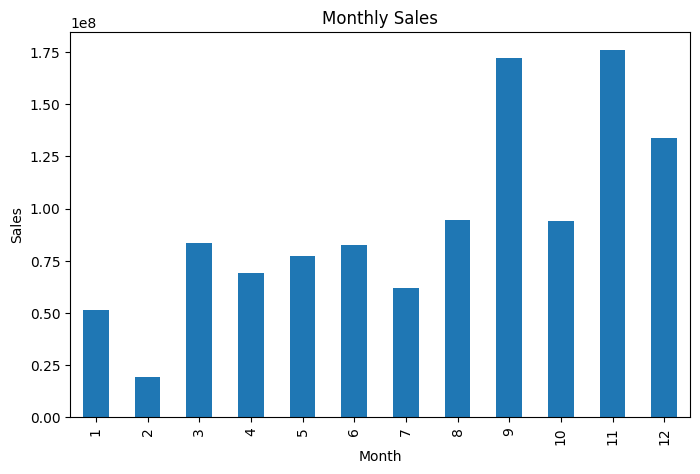

In [39]:
monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

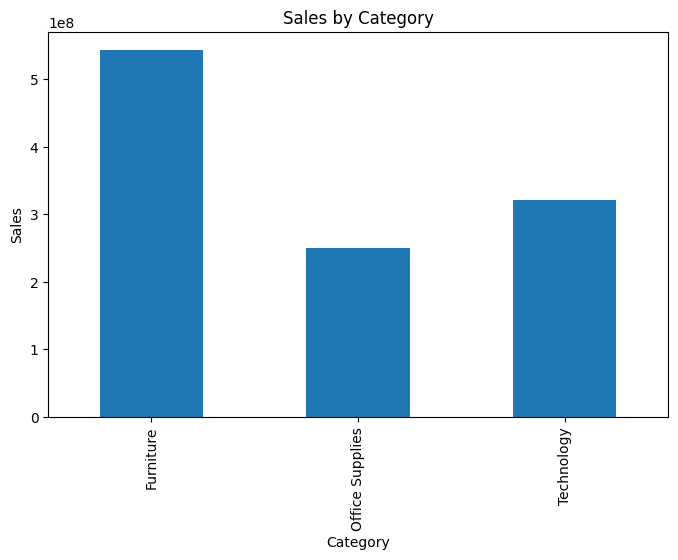

In [40]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

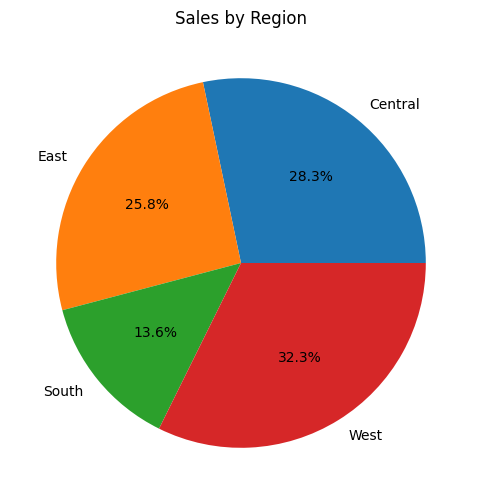

In [41]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(6,6))
region_sales.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Sales by Region")
plt.show()

In [ ]:
# Business Insights

## Forecast Summary
The machine learning model predicts future sales based on historical sales data. By analyzing past sales patterns, it estimates expected sales for upcoming dates.

## Business Benefits
- Helps businesses plan inventory and avoid stock shortages.
- Assists managers in scheduling staff based on expected demand.
- Supports budgeting and cash flow planning.
- Helps identify seasonal sales trends.
- Enables better business decisions using data-driven forecasts.

## Conclusion
Sales forecasting allows businesses to prepare for future demand, reduce losses, and improve overall operational efficiency.